<h3 align="center"><i> Object Oriented Programming in Java - 22AIE111 </i></h3>
<h3 align="center"><i> Data Structures and Algorithms - 22AIE112 </i> </h3>
<h3 align="center"><i> FINAL REVIEW PRESENTATION - 15/04/2025 </i> </h3>

<h4><i><b> PROJECT TITLE :</h4>
<h5> <i> eCommerce Website Inventory Management using Binary Search Tree (BST) </h5>

<h5> KEY FEATURES: </h5>
<h5> 1. INSERTION <br> 2. DELETION <br> 3.SEARCH BY PRODUCT ID <br> 4.SEARCH BY PRODUCT CATEGORY <br> 5. SHOP PRDUCTS AND UPDATE INVENTORY <br> 6. USER AUTHENTICATION </h5>


<h5> FINAL WORKING CODE (USING STREAMLIT) </h5>
<h5> NECESSARY LIBRARIES </h5>

In [ ]:
import streamlit as st    #for user interface 
import pandas as pd #for handling structured data, data manipulation and analysis
import plotly.express as px   #to create interactive visualizations and plotting various graphs


<h5> PAGE CONFIGURATION </h5>

```python
    st.set_page_config(
    page_title="eCommerce Website Inventory Management",
    page_icon="🌍",
    layout="wide",
    initial_sidebar_state="expanded"
)

<h5> EMBEDDED CSS FOR STYLING THE WEBPAGE </h5>


```css
<style>
    .main-header {
        font-size: 2.5rem;
        color: #4b4b4b;
        text-align: center;
        padding: 1rem 0;
        border-bottom: 2px solid #f0f0f0;
        margin-bottom: 2rem;
    }
    .page-subtitle {
        font-size: 1.5rem;
        color: #6c757d;
        margin-bottom: 1rem;
    }
    .card {
        border-radius: 10px;
        border: 1px solid #e0e0e0;
        padding: 1.5rem;
        margin-bottom: 1rem;
        background-color: #f9f9f9;
    }
    .success-message {
        background-color: #d4edda;
        color: #155724;
        padding: 1rem;
        border-radius: 5px;
        margin: 1rem 0;
    }
    .error-message {
        background-color: #f8d7da;
        color: #721c24;
        padding: 1rem;
        border-radius: 5px;
        margin: 1rem 0;
    }
    .login-container {
        max-width: 500px;
        margin: 0 auto;
        padding: 2rem;
        background-color: #f8f9fa;
        border-radius: 10px;
        box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
    }
    .login-header {
        text-align: center;
        margin-bottom: 2rem;
    }
    .login-button {
        text-align: center;
        margin-top: 1rem;
    }
    .user-info {
        padding: 0.5rem 1rem;
        background-color: #e9ecef;
        border-radius: 5px;
        margin-bottom: 1rem;
        font-weight: bold;
    }
    .metric-container {
        background-color: #e9ecef;
        border-radius: 10px;
        padding: 1rem;
        text-align: center;
    }
    .sidebar .sidebar-content {
        background-color: #f8f9fa;
    }
    .sidebar .sidebar-content .block-container {
        padding-top: 2rem;
    }
    div[data-testid="stMetricValue"] {
        font-size: 1.8rem;
        font-weight: bold;
        color: #0366d6;
    }
    div[data-testid="stMetricLabel"] {
        font-size: 1.2rem;
        font-weight: normal;
        color: #6c757d;
    }
</style>


<h5> PRODUCT CLASS</h5>

```python
class Product:
    def __init__(self, id, name, category, quantity, price, description=""):
        self.id = id
        self.name = name
        self.category = category
        self.quantity = quantity
        self.price = price
        self.description = description

    def __str__(self): #USE OF POLYMORPHISM-METHOD OVERRIDING, redefining __str__() method in base class to construct the type of wanted return value
        
        return f"ID: {self.id}, Name: {self.name}, Category: {self.category}, Quantity: {self.quantity}, Price: ₹{self.price:.2f}"
    
    def to_dict(self): #to return product related information in a dictionary key-value pairs 
        return {
            "id": self.id,
            "name": self.name,
            "category": self.category,
            "quantity": self.quantity,
            "price": self.price,
            "description": self.description
        }

class ElectronicsProduct(Product):
    def __init__(self, id, name, quantity, price, description=""):
        super().__init__(id, name, "Electronics", quantity, price, description)

class ClothingProduct(Product):
    def __init__(self, id, name, quantity, price, description=""):
        super().__init__(id, name, "Clothing", quantity, price, description)

class AccessoriesProduct(Product):
    def __init__(self, id, name, quantity, price, description=""):
        super().__init__(id, name, "Accessories", quantity, price, description)

# super().__init__() method calls the constructor of the next class according to Method Resolution Order 

<h5> Implementation of Binary Search Tree (BST) </h5>
Extra features: <br>
1. Self balancing tendencies (Left and Right rotation to balance RR and LL imbalances respectively) <br>
2. Returning and updating Height of Binary Search Tree 

```python
class Node:
    def __init__(self, product):
        self.product = product
        self.left = None
        self.right = None
        self.height = 1

class InventoryBST:
    def __init__(self):
        self.root = None
    
    def get_height(self, node):
        return 0 if not node else node.height
    
    def get_balance(self, node):
        return 0 if not node else self.get_height(node.left) - self.get_height(node.right)
    
    def update_height(self, node):
        if node:
            node.height = 1 + max(self.get_height(node.left), self.get_height(node.right))
    
    def right_rotate(self, y):
        x = y.left
        T2 = x.right
        x.right = y
        y.left = T2
        self.update_height(y)
        self.update_height(x)
        return x
    
    def left_rotate(self, x):
        y = x.right
        T2 = y.left
        y.left = x
        x.right = T2
        self.update_height(x)
        self.update_height(y)
        return y
    
    def insert(self, product):
        self.root = self._insert_rec(self.root, product)
    
    def _insert_rec(self, root, product):
        if not root:
            return Node(product)
        
        if product.id < root.product.id:
            root.left = self._insert_rec(root.left, product)
        elif product.id > root.product.id:
            root.right = self._insert_rec(root.right, product)
        else:
            # If product with same ID exists, we update its details
            root.product = product
            return root
        
        self.update_height(root)
        balance = self.get_balance(root)
        
        # Left Left Case
        if balance > 1 and product.id < root.left.product.id:
            return self.right_rotate(root)
        
        # Right Right Case
        if balance < -1 and product.id > root.right.product.id:
            return self.left_rotate(root)
        
        # Left Right Case
        if balance > 1 and product.id > root.left.product.id:
            root.left = self.left_rotate(root.left)
            return self.right_rotate(root)
        
        # Right Left Case
        if balance < -1 and product.id < root.right.product.id:
            root.right = self.right_rotate(root.right)
            return self.left_rotate(root)
        
        return root
    
    def inorder(self):
        products = []
        self._inorder_rec(self.root, products)
        return products
    
    def _inorder_rec(self, root, products):
        if root:
            self._inorder_rec(root.left, products)
            products.append(root.product)
            self._inorder_rec(root.right, products)
    
    def search_by_id(self, id):
        return self._search(self.root, id)
    
    def _search(self, root, id):
        if root is None or root.product.id == id:
            return root
        if id < root.product.id:
            return self._search(root.left, id)
        return self._search(root.right, id)
    
    def search_by_category(self, category):
        results = []
        self._search_by_category_rec(self.root, category.lower(), results)
        return results
    
    def _search_by_category_rec(self, root, category, results):
        if root:
            self._search_by_category_rec(root.left, category, results)
            if root.product.category.lower() == category.lower():
                results.append(root.product)
            self._search_by_category_rec(root.right, category, results)
    
    def delete(self, id):
        self.root = self._delete_rec(self.root, id)
    
    def _delete_rec(self, root, id):
        if not root:
            return root
        
        if id < root.product.id:
            root.left = self._delete_rec(root.left, id)
        elif id > root.product.id:
            root.right = self._delete_rec(root.right, id)
        else:
            if not root.left:
                return root.right
            elif not root.right:
                return root.left
            
            successor = self._min_value_node(root.right)
            root.product = successor.product
            root.right = self._delete_rec(root.right, successor.product.id)
        
        if not root:
            return root
        
        self.update_height(root)
        balance = self.get_balance(root)
        
        # Balance if needed
        if balance > 1 and self.get_balance(root.left) >= 0:
            return self.right_rotate(root)
        
        if balance > 1 and self.get_balance(root.left) < 0:
            root.left = self.left_rotate(root.left)
            return self.right_rotate(root)
        
        if balance < -1 and self.get_balance(root.right) <= 0:
            return self.left_rotate(root)
        
        if balance < -1 and self.get_balance(root.right) > 0:
            root.right = self.right_rotate(root.right)
            return self.left_rotate(root)
        
        return root
    
    def _min_value_node(self, node):
        current = node
        while current.left:
            current = current.left
        return current


<h5> Driver Class - Inventory System Main Class </h5>

```python
class InventorySystem:
    def __init__(self):
        self.inventory = InventoryBST()
        self.initialize_inventory()
    
    def initialize_inventory(self):
        products = [
            ElectronicsProduct(1, "Laptop", 10, 999.99, "High-performance laptop with latest specs"),
            ElectronicsProduct(2, "Smartphone", 20, 699.99, "Latest model with advanced camera"),
            ElectronicsProduct(3, "Headphones", 30, 149.99, "Noise-cancelling wireless headphones"),
            ClothingProduct(4, "T-shirt", 50, 19.99, "100% cotton, comfortable fit"),
            ClothingProduct(5, "Jeans", 25, 39.99, "Durable denim with stylish wash"),
            ClothingProduct(7, "Winter Jacket", 15, 89.99, "Warm jacket for cold weather"),
            AccessoriesProduct(6, "Wrist Watch", 10, 99.99, "Elegant timepiece with leather strap"),
            AccessoriesProduct(8, "Sunglasses", 40, 29.99, "UV protection with trendy design"),
            AccessoriesProduct(9, "Backpack", 35, 49.99, "Spacious backpack with multiple compartments")
        ]
        for product in products:
            self.inventory.insert(product)
    
    def get_all_products(self):
        # Fixed implementation to correctly traverse the BST
        products = []
        self._inorder_rec(self.inventory.root, products)
        return products
    
    def _inorder_rec(self, root, products):
        if root:
            self._inorder_rec(root.left, products)
            products.append(root.product)
            self._inorder_rec(root.right, products)
    
    def search_product_by_id(self, id):
        result = self.inventory.search_by_id(id)
        return result.product if result else None
    
    def search_products_by_category(self, category):
        return self.inventory.search_by_category(category)
    
    def add_product(self, id, name, category, quantity, price, description=""):
        if category.lower() == "electronics":
            product = ElectronicsProduct(id, name, quantity, price, description)
        elif category.lower() == "clothing":
            product = ClothingProduct(id, name, quantity, price, description)
        elif category.lower() == "accessories":
            product = AccessoriesProduct(id, name, quantity, price, description)
        else:
            product = Product(id, name, category, quantity, price, description)
        
        self.inventory.insert(product)
        return product
    
    def delete_product(self, id):
        self.inventory.delete(id)
    
    def reduce_product_quantity(self, id, quantity_to_reduce):
        """Reduce product quantity by specified amount and return success"""
        result = self.inventory.search_by_id(id)
        if result and result.product.quantity >= quantity_to_reduce:
            result.product.quantity -= quantity_to_reduce
            return True
        return False
    
    def get_categories(self):
        products = self.get_all_products()
        return sorted(list(set(p.category for p in products)))


<h5> Cart and Checkout Functionality </h5>

```python
def add_to_cart(product_id, quantity):
    """Add product to cart with specified quantity"""
    if product_id in st.session_state.cart:
        st.session_state.cart[product_id] += quantity
    else:
        st.session_state.cart[product_id] = quantity
    
    # Check if we're not exceeding available inventory
    product = st.session_state.inventory_system.search_product_by_id(product_id)
    if product and st.session_state.cart[product_id] > product.quantity:
        st.session_state.cart[product_id] = product.quantity
        st.warning(f"Quantity adjusted to available stock ({product.quantity})")
    else:
        st.success(f"Added {quantity} of {product.name} to cart")

def update_cart_quantity(product_id, new_quantity):
    """Update product quantity in cart"""
    product = st.session_state.inventory_system.search_product_by_id(product_id)
    
    if new_quantity <= 0:
        # Remove from cart if quantity is 0 or negative
        if product_id in st.session_state.cart:
            del st.session_state.cart[product_id]
    else:
        # Check if we have enough inventory
        if new_quantity > product.quantity:
            st.session_state.cart[product_id] = product.quantity
            st.warning(f"Quantity adjusted to available stock ({product.quantity})")
        else:
            st.session_state.cart[product_id] = new_quantity

def remove_from_cart(product_id):
    """Remove product from cart"""
    if product_id in st.session_state.cart:
        del st.session_state.cart[product_id]

def clear_cart():
    """Clear all items from cart"""
    st.session_state.cart = {}

def get_cart_items():
    """Get cart items with product details"""
    cart_items = []
    for product_id, quantity in st.session_state.cart.items():
        product = st.session_state.inventory_system.search_product_by_id(product_id)
        if product:
            cart_item = {
                "id": product.id,
                "name": product.name,
                "category": product.category,
                "price": product.price,
                "quantity": quantity,
                "total": product.price * quantity
            }
            cart_items.append(cart_item)
    return cart_items

def get_cart_total():
    """Calculate cart total before tax"""
    cart_items = get_cart_items()
    return sum(item["total"] for item in cart_items)

def get_cart_count():
    """Get total number of items in cart"""
    return sum(st.session_state.cart.values())

def process_checkout():
    """Process checkout and update inventory"""
    success = True
    failed_items = []
    
    # Verify all items are in stock
    for product_id, quantity in st.session_state.cart.items():
        product = st.session_state.inventory_system.search_product_by_id(product_id)
        if not product or product.quantity < quantity:
            success = False
            failed_items.append(product.name if product else f"Product ID {product_id}")
    
    if success:
        # Update inventory quantities
        for product_id, quantity in st.session_state.cart.items():
            st.session_state.inventory_system.reduce_product_quantity(product_id, quantity)
        
        # Clear cart after successful checkout
        clear_cart()
        st.session_state.checkout_success = True
        return True, None
    else:
        return False, failed_items

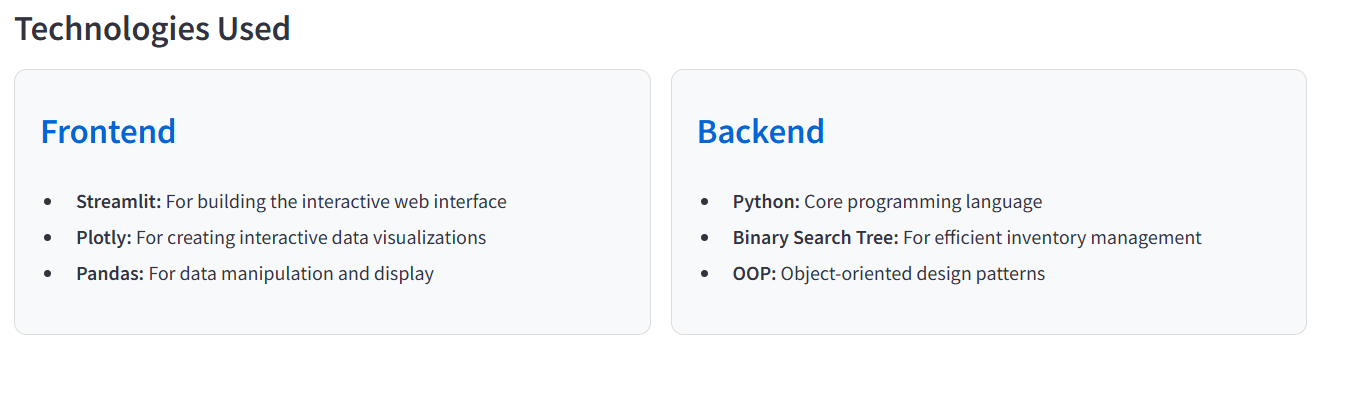
